In [109]:
import numpy as np
import pandas as pd
import astropy.units as u

from astropy.coordinates import cartesian_to_spherical
from numpy.polynomial import Polynomial as P

In [167]:
# import funcs

%run ./utils.ipynb

In [5]:
source = '/cosma5/data/durham/dc-pick2/simulations'

In [225]:
hyades_path = source + '/Hyades'
times = [600]

step, glob_df, Myr_per_Nbody = get_steps_at_times(hyades_path, times)
step_df = step[600]

/tmp/ipykernel_3792244/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


In [191]:
step_df

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z,R,LAT,LON
0,0.017380,3096,-0.150068,2.873971,0.567792,0.757047,-1043.450073,537.539734,-16.143837,1173.881444,-0.013753,2.665894
1,0.089583,4377,-0.146794,2.091799,0.682195,1.224897,-1043.888916,535.934204,-18.068363,1173.565510,-0.015397,2.667281
2,0.012537,7398,-0.145626,2.255207,1.601812,1.072176,-1043.901855,538.349304,-16.412458,1174.657578,-0.013973,2.665457
3,1.191852,2738,-0.148580,1.760767,0.470834,0.936493,-1043.205566,537.677734,-16.326563,1173.729848,-0.013910,2.665694
4,0.054072,2241,-0.155790,1.981243,1.626340,1.106368,-1043.612305,538.055542,-15.968308,1174.259509,-0.013599,2.665567
...,...,...,...,...,...,...,...,...,...,...,...,...
8449,0.012893,7451,-0.058077,2.000656,0.766159,0.818289,-1037.283203,508.142303,-13.125261,1155.135194,-0.011363,2.686075
8450,0.478688,7161,-0.059400,1.543559,0.778369,1.457630,-1018.890076,551.872253,-17.456345,1158.880794,-0.015064,2.645190
8451,0.325312,7047,-0.035527,1.356145,2.190726,0.645631,-1076.270264,595.098755,-23.703798,1230.065884,-0.019272,2.636505
8452,0.081077,1870,-0.089244,1.834443,0.836257,0.078898,-1040.456909,545.337524,-29.844770,1175.089063,-0.025401,2.658826


In [226]:
step_df['R'], step_df['LAT'], step_df['LON'] = cartesian_to_spherical(step_df['X'], step_df['Y'], step_df['Z'])


In [34]:
print(step_df[['X', 'Y', 'Z']].dtypes)
print(type(step_df['X'].iloc[0]))

X    float32
Y    float32
Z    float32
dtype: object
<class 'numpy.float32'>


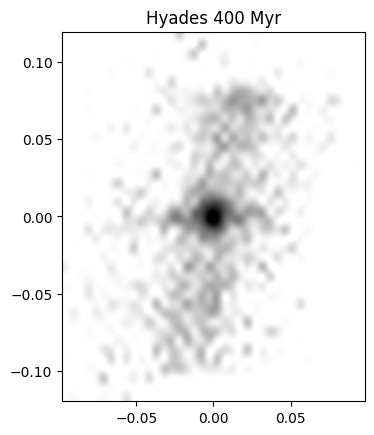

In [230]:
fig, ax = plt.subplots()
# Convert before passing in
plot_clustergram_rad(fig, ax, step_df['LAT'], step_df['LON'],
                     title='Hyades 400 Myr', acceptance=99.5, m=step_df['M'])


plt.show()

In [228]:
DEG_TO_RAD = np.pi / 180
DENSITY_THRESHOLD = 20 / DEG_TO_RAD**2
MIN_LENGTH = 10 * DEG_TO_RAD 

#def ridge_fit(lat, lon, m, bins=40, deg=4, density_cutoff=DENSITY_THRESHOLD, length_min=MIN_LENGTH):

latdata = step_df['LAT']
londata = step_df['LON']
m = step_df['M']
bins=200
deg=4



latdata = np.array(latdata, dtype=float)
londata = np.array(londata, dtype=float)

com_lat = np.median(latdata) #TODO swap to use sphere
com_lon = np.median(londata)

lat_c = latdata - com_lat
lon_c = londata - com_lon

hist, xedges, yedges = np.histogram2d(
lon_c, lat_c,
bins=bins,
weights=m)

x_centres = 0.5 * (xedges[:-1] + xedges[1:])  # lon
y_centres = 0.5 * (yedges[:-1] + yedges[1:])  # lat

bin_area = ((xedges[-1]-xedges[0])/bins) * ((yedges[-1]-yedges[0])/bins)
density = hist / bin_area

peak_lon_idx = np.argmax(density, axis=0)

peak_lons = x_centres[peak_lon_idx]
peak_dens = density[peak_lon_idx, np.arange(len(y_centres))]
mask = peak_dens > DENSITY_THRESHOLD
valid_lats = y_centres[mask]
valid_lons = peak_lons[mask]



if np.abs(valid_lats[-1] - valid_lats[0]) < MIN_LENGTH:
    pass
    #return None


poly = P.fit(valid_lats, valid_lons, deg)







In [176]:
step_df['M'].sum()

np.float32(1455.7698)

In [155]:
poly

Polynomial([ 0.00821932, -0.0009109 , -0.00070848,  0.0009109 ,  0.0009109 ], domain=[-0.01213861,  0.07446761], window=[-1.,  1.], symbol='x')

In [197]:
valid_lats

array([-0.10054912, -0.08250616, -0.0644632 , -0.04642023, -0.02837727,
       -0.01033431,  0.00770865,  0.02575161,  0.04379457,  0.06183754,
        0.0798805 ])

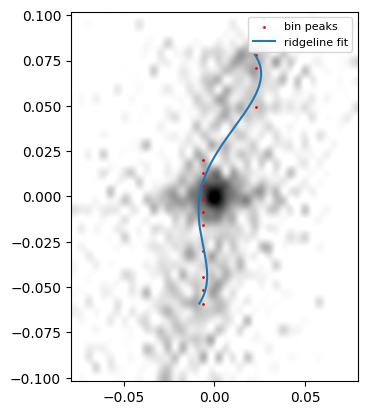

In [229]:
fig, ax = plt.subplots()
plot_clustergram_rad(fig, ax, step_df['LAT'], step_df['LON'], acceptance=99, m=step_df['M'])

ax.scatter(valid_lons, valid_lats, s=1, c='red', label='bin peaks')

lat_smooth = np.linspace(valid_lats[0], valid_lats[-1], 500)
ax.plot(poly(lat_smooth), lat_smooth, label='ridgeline fit')

ax.legend(fontsize=8)
plt.show()